
# Scenario‑1 MTTD Analysis Notebook

This notebook analyzes **Mean Time To Detect (MTTD)** for Scenario‑1 exfiltrators
using the full `alerts.ndjson` produced by `src/run_loop.py`.

It:
- Loads Scenario‑1 ground truth from `answers/insiders.csv`
- Loads all alerts from `out/<release>/.../alerts_ndjson/alerts.ndjson`
- Filters to Scenario‑1 exfil users
- Aggregates daily scores per detector
- Computes per‑user lead time for a given detector + threshold
- Sweeps thresholds for each detector to see natural lead‑time ranges

You can tweak file paths and threshold grids as needed.


In [16]:

# Cell 1: imports and basic config

import json
from pathlib import Path
from datetime import date, datetime

import pandas as pd
import numpy as np

pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


In [17]:
from pathlib import Path

# Run this notebook from **repo root**:
#   cd /Users/jordanchambers/capstone_6019
#   jupyter lab / code notebook, etc.

# Go up from notebooks/ml → notebooks → repo root
REPO_ROOT = Path.cwd().parents[1]

# Example default: MVP0 alerts
ALERTS_PATH = REPO_ROOT / "out" / "r5.2" / "alerts_full" / "alerts.ndjson"

# If you're running a release-specific run, point here instead:
# ALERTS_PATH = REPO_ROOT / "out" / "r5.2" / "alerts_ndjson" / "alerts.ndjson"

ANSWERS_PATH = REPO_ROOT / "answers" / "insiders.csv"

DATASET_ID = "5.2"   # CERT dataset id as string in insiders.csv
SCENARIO_ID = 1      # Scenario 1 (USB + after-hours + Wikileaks)

print("REPO_ROOT  :", REPO_ROOT)
print("ALERTS_PATH:", ALERTS_PATH)
print("ANSWERS_PATH:", ANSWERS_PATH)

REPO_ROOT  : /Users/jordanchambers/capstone_6019
ALERTS_PATH: /Users/jordanchambers/capstone_6019/out/r5.2/alerts_full/alerts.ndjson
ANSWERS_PATH: /Users/jordanchambers/capstone_6019/answers/insiders.csv


In [18]:

# Cell 3: load Scenario‑1 exfil ranges and compute per‑user exfil_start

answers = pd.read_csv(ANSWERS_PATH)

answers["dataset"] = answers["dataset"].astype(str)
answers["scenario"] = answers["scenario"].astype(int)

s1 = answers[
    (answers["dataset"] == DATASET_ID) &
    (answers["scenario"] == SCENARIO_ID)
].copy()

# Normalize user_key and parse exfil_start / exfil_end
s1["user_key"] = s1["user"].astype(str).str.lower()
s1["exfil_start"] = pd.to_datetime(s1["start"], format="%m/%d/%Y %H:%M:%S").dt.date
s1["exfil_end"]   = pd.to_datetime(s1["end"],   format="%m/%d/%Y %H:%M:%S").dt.date

exfil_by_user = (
    s1.groupby("user_key", as_index=False)
      .agg({"exfil_start": "min", "exfil_end": "max"})
)

print("Scenario‑1 exfil users:", len(exfil_by_user))
exfil_by_user.head()


Scenario‑1 exfil users: 29


,user_key,exfil_start,exfil_end
0,alt1465,2010-08-13,2010-08-20
1,alw0764,2011-02-03,2011-02-05
2,ayg1697,2010-10-25,2010-10-26
3,das1320,2010-07-09,2010-07-15
4,dnj0740,2010-10-04,2010-10-05


In [19]:

# Cell 4: load alerts.ndjson and basic cleaning

rows = []
with ALERTS_PATH.open("r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
            rows.append(obj)
        except json.JSONDecodeError:
            # Skip malformed lines
            continue

alerts = pd.DataFrame(rows)
print("Raw alerts rows:", len(alerts))
alerts.head()


Raw alerts rows: 57568


,day,user_key,detector,reason,score,evidence,human_summary,rules_score,anomaly_score,forecast_score
0,2010-01-02,aab1302,loop,heartbeat,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-03,acc0950,loop,heartbeat,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-04,emr0269,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
3,2010-01-04,vrp0267,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
4,2010-01-04,aab1302,loop,heartbeat,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:

# Cell 4b: normalize user_key, parse day, remove heartbeat rows

if "user_key" not in alerts.columns:
    raise ValueError("alerts.ndjson is missing 'user_key' column")

alerts["user_key"] = alerts["user_key"].astype(str).str.lower()

# Remove run_loop heartbeat rows
alerts = alerts[alerts["detector"] != "loop"].copy()

# Parse day as date
alerts["day"] = pd.to_datetime(alerts["day"]).dt.date

print("Alerts after removing heartbeats:", len(alerts))
print(alerts["detector"].value_counts())
alerts.head()


Alerts after removing heartbeats: 57051
detector
anomaly     54103
forecast     2201
rules         631
ml            116
Name: count, dtype: int64


,day,user_key,detector,reason,score,evidence,human_summary,rules_score,anomaly_score,forecast_score
2,2010-01-04,emr0269,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
3,2010-01-04,vrp0267,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
5,2010-01-05,emr0269,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 3, 'usb_days_7d': 4, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
6,2010-01-05,ezb0925,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 1, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN
7,2010-01-05,ocw1127,rules,rules:s1_near_miss,0.3,"{'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...",Possible preparation for data theft: after-hou...,NaN,NaN,NaN


In [21]:

# Cell 5: restrict alerts to Scenario‑1 exfiltrator users

s1_users = set(exfil_by_user["user_key"])
alerts_s1 = alerts[alerts["user_key"].isin(s1_users)].copy()

print("Alerts for Scenario‑1 users:", len(alerts_s1))
print(alerts_s1["detector"].value_counts())
alerts_s1.head()


Alerts for Scenario‑1 users: 967
detector
anomaly     515
forecast    225
ml          116
rules       111
Name: count, dtype: int64


,day,user_key,detector,reason,score,evidence,human_summary,rules_score,anomaly_score,forecast_score
2376,2010-01-22,dnj0740,forecast,forecast:s1_exfil_7d,0.537334,{},NaN,NaN,NaN,NaN
2647,2010-01-25,dnj0740,forecast,forecast:s1_exfil_7d,0.727472,{},NaN,NaN,NaN,NaN
2847,2010-01-26,dnj0740,forecast,forecast:s1_exfil_7d,0.699153,{},NaN,NaN,NaN,NaN
3135,2010-01-27,saf1942,forecast,forecast:s1_exfil_7d,0.753664,{},NaN,NaN,NaN,NaN
6629,2010-02-25,das1320,forecast,forecast:s1_exfil_7d,0.611604,{},NaN,NaN,NaN,NaN


In [22]:

# Cell 6: aggregate to daily max score per (user_key, day, detector)

if "score" not in alerts_s1.columns:
    raise ValueError("alerts.ndjson is missing 'score' column used for MTTD analysis.")

daily = (
    alerts_s1.groupby(["user_key", "day", "detector"], as_index=False)
             .agg({"score": "max"})
)

print("Daily detector rows:", len(daily))
daily.head()


Daily detector rows: 967


,user_key,day,detector,score
0,alt1465,2010-08-11,forecast,0.908962
1,alt1465,2010-08-12,forecast,0.903343
2,alt1465,2010-08-13,forecast,0.808813
3,alt1465,2010-08-13,ml,0.544195
4,alt1465,2010-08-14,forecast,0.649446


In [23]:

# Cell 7: join exfil_start onto daily scores

daily = daily.merge(exfil_by_user, on="user_key", how="left")

missing_exfil = daily["exfil_start"].isna().sum()
print("Rows missing exfil_start:", missing_exfil)

daily.head()


Rows missing exfil_start: 0


,user_key,day,detector,score,exfil_start,exfil_end
0,alt1465,2010-08-11,forecast,0.908962,2010-08-13,2010-08-20
1,alt1465,2010-08-12,forecast,0.903343,2010-08-13,2010-08-20
2,alt1465,2010-08-13,forecast,0.808813,2010-08-13,2010-08-20
3,alt1465,2010-08-13,ml,0.544195,2010-08-13,2010-08-20
4,alt1465,2010-08-14,forecast,0.649446,2010-08-13,2010-08-20


In [24]:

# Cell 8: helper to compute lead times for a given detector + threshold

def compute_lead_times(df: pd.DataFrame, detector: str, threshold: float, inclusive: bool = True) -> pd.DataFrame:
    """
    For the given detector and threshold, compute per‑user lead time:

        lead_time_days = max((exfil_start - first_signal_day).days, 0)

    Returns a DataFrame with columns:
        user_key, first_signal_day, exfil_start, lead_time_days
    Only includes users with at least one signal before or on exfil_start.
    """
    sub = df[df["detector"] == detector].copy()
    if sub.empty:
        return pd.DataFrame(columns=["user_key", "first_signal_day", "exfil_start", "lead_time_days"])

    # Filter rows by score threshold
    if inclusive:
        sub = sub[sub["score"] >= threshold].copy()
    else:
        sub = sub[sub["score"] > threshold].copy()

    if sub.empty:
        return pd.DataFrame(columns=["user_key", "first_signal_day", "exfil_start", "lead_time_days"])

    # Earliest signal per user
    first_sig = (
        sub.groupby("user_key", as_index=False)
           .agg({"day": "min", "exfil_start": "first"})
           .rename(columns={"day": "first_signal_day"})
    )

    lead_times = []
    for _, row in first_sig.iterrows():
        exfil = row["exfil_start"]
        first = row["first_signal_day"]
        if pd.isna(exfil) or pd.isna(first):
            lead_times.append(np.nan)
        else:
            delta = (exfil - first).days
            # Clip negatives: if the "first signal" is after exfil_start,
            # treat it as 0 days of lead time (no early warning).
            lead_times.append(max(delta, 0))

    first_sig["lead_time_days"] = lead_times
    first_sig = first_sig.dropna(subset=["lead_time_days"])

    return first_sig


In [25]:

# Cell 9: quick single‑threshold MTTD sanity check per detector

# You can adjust these thresholds based on how your scores behave.
thresholds = {
    "rules": 0.3,     # s1_near_miss and up
    "anomaly": 0.5,   # boosted anomaly score
    "forecast": 0.5,  # forecast probability threshold
    "ml": 0.5,        # supervised detector probability
}

for det, thr in thresholds.items():
    if det not in daily["detector"].unique():
        print(f"Detector={det}: no rows present in alerts.ndjson; skipping.")
        continue

    lt = compute_lead_times(daily, detector=det, threshold=thr)
    if lt.empty:
        print(f"Detector={det}, thr={thr}: no users met the threshold before exfil_start.")
        continue

    print(f"""
Detector={det}, threshold={thr}
  users with early signal: {len(lt)} / {len(s1_users)}
  mean lead time (days):   {lt['lead_time_days'].mean():.1f}
  median lead time (days): {lt['lead_time_days'].median():.1f}
  min / max (days):        {lt['lead_time_days'].min():.1f} / {lt['lead_time_days'].max():.1f}
""".strip())


Detector=rules, threshold=0.3
  users with early signal: 27 / 29
  mean lead time (days):   2.3
  median lead time (days): 1.0
  min / max (days):        0.0 / 14.0
Detector=anomaly, threshold=0.5
  users with early signal: 29 / 29
  mean lead time (days):   1.9
  median lead time (days): 0.0
  min / max (days):        0.0 / 14.0
Detector=forecast, threshold=0.5
  users with early signal: 28 / 29
  mean lead time (days):   51.3
  median lead time (days): 6.0
  min / max (days):        0.0 / 341.0
Detector=ml, threshold=0.5
  users with early signal: 28 / 29
  mean lead time (days):   0.6
  median lead time (days): 0.0
  min / max (days):        0.0 / 8.0


In [26]:

# Cell 10: sweep thresholds for a detector and collect summary stats

from typing import List

def sweep_thresholds(df: pd.DataFrame, detector: str, thr_values: List[float]) -> pd.DataFrame:
    records = []
    for thr in thr_values:
        lt = compute_lead_times(df, detector=detector, threshold=thr)
        if lt.empty:
            records.append({
                "detector": detector,
                "threshold": thr,
                "n_users": 0,
                "mean_lead": np.nan,
                "median_lead": np.nan,
                "min_lead": np.nan,
                "max_lead": np.nan,
            })
            continue

        records.append({
            "detector": detector,
            "threshold": thr,
            "n_users": len(lt),
            "mean_lead": lt["lead_time_days"].mean(),
            "median_lead": lt["lead_time_days"].median(),
            "min_lead": lt["lead_time_days"].min(),
            "max_lead": lt["lead_time_days"].max(),
        })

    return pd.DataFrame(records)


In [27]:

# Cell 11: run a threshold sweep for all detectors and inspect results

thr_grid = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

results = []
for det in ["rules", "anomaly", "forecast", "ml"]:
    if det not in daily["detector"].unique():
        continue
    res = sweep_thresholds(daily, detector=det, thr_values=thr_grid)
    results.append(res)

if results:
    sweep_df = pd.concat(results, ignore_index=True)
    sweep_df
else:
    sweep_df = pd.DataFrame()
    print("No detectors found in alerts.ndjson for sweep.")


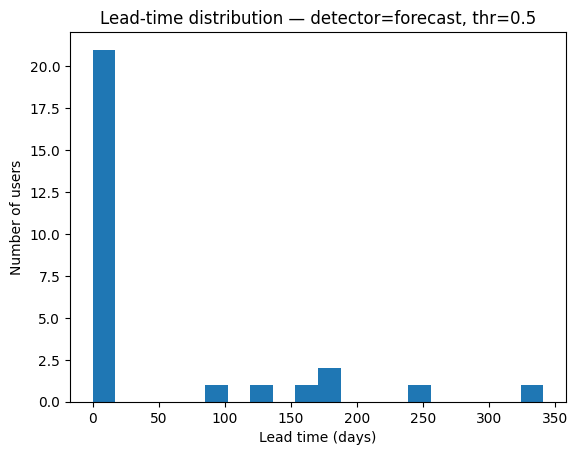

In [28]:

# Cell 12: example per‑user lead time distribution plot (optional)

import matplotlib.pyplot as plt

det = "forecast"   # change to "rules", "anomaly", or "ml" as needed
thr = 0.5

if det in daily["detector"].unique():
    lt = compute_lead_times(daily, detector=det, threshold=thr)
    valid = lt["lead_time_days"].dropna()

    if not valid.empty:
        plt.figure()
        plt.hist(valid, bins=20)
        plt.xlabel("Lead time (days)")
        plt.ylabel("Number of users")
        plt.title(f"Lead‑time distribution — detector={det}, thr={thr}")
        plt.show()
    else:
        print(f"No valid lead times for detector={det}, thr={thr}.")
else:
    print(f"Detector={det} not present in 'daily' table.")


In [29]:
print("=== exfil_by_user ===")
print(exfil_by_user.shape)
print(exfil_by_user.head(10))
print()

print("=== alerts (all) ===")
print(alerts.shape)
print(alerts["detector"].value_counts())
print(alerts.head(5))
print()

print("=== alerts_s1 (S1 exfil users only) ===")
print(alerts_s1.shape)
print(alerts_s1["detector"].value_counts())
print(alerts_s1.head(5))
print()

print("=== daily (aggregated) ===")
print(daily.shape)
print(daily["detector"].value_counts())
print(daily.head(5))
print()

print("=== sweep_df (if it exists) ===")
try:
    print(sweep_df.shape)
    print(sweep_df.head(20))
except NameError as e:
    print("sweep_df not defined:", e)

=== exfil_by_user ===
(29, 3)
  user_key exfil_start   exfil_end
0  alt1465  2010-08-13  2010-08-20
1  alw0764  2011-02-03  2011-02-05
2  ayg1697  2010-10-25  2010-10-26
3  das1320  2010-07-09  2010-07-15
4  dnj0740  2010-10-04  2010-10-05
5  elt1370  2011-02-03  2011-02-10
6  epg1196  2010-07-15  2010-07-20
7  etw0002  2011-03-17  2011-03-17
8  fzg0389  2010-12-10  2010-12-17
9  gfm1815  2010-07-16  2010-07-16

=== alerts (all) ===
(57051, 10)
detector
anomaly     54103
forecast     2201
rules         631
ml            116
Name: count, dtype: int64
          day user_key detector              reason  score                                           evidence  \
2  2010-01-04  emr0269    rules  rules:s1_near_miss    0.3  {'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...   
3  2010-01-04  vrp0267    rules  rules:s1_near_miss    0.3  {'ah_sig_days_7d': 2, 'usb_days_7d': 3, 'usb_t...   
5  2010-01-05  emr0269    rules  rules:s1_near_miss    0.3  {'ah_sig_days_7d': 3, 'usb_days_7d': 4, 'usb_

: 